# Simple Linear Regression — Salary Prediction

- **Dataset:** `Salary_Data.csv`
- **Feature:** YearsExperience
- **Target:** Salary
- **Model:** `sklearn.linear_model.LinearRegression`

## 1. Import Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Load Dataset

In [2]:
df = pd.read_csv(r'..\datasets\Salary_Data.csv')

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.shape

(30, 2)

## 3. Basic EDA

In [5]:
# Dataset structure
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [7]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
# Missing values
print('Missing values:')
print(df.isnull().sum())

# Duplicate rows
print('\nDuplicate rows:', df.duplicated().sum())

# Handle missing values and duplicates if present
df = df.drop_duplicates().dropna().reset_index(drop=True)

print('\nShape after cleaning:', df.shape)

Missing values:
YearsExperience    0
Salary             0
dtype: int64

Duplicate rows: 0

Shape after cleaning: (30, 2)


## 4. Visualization

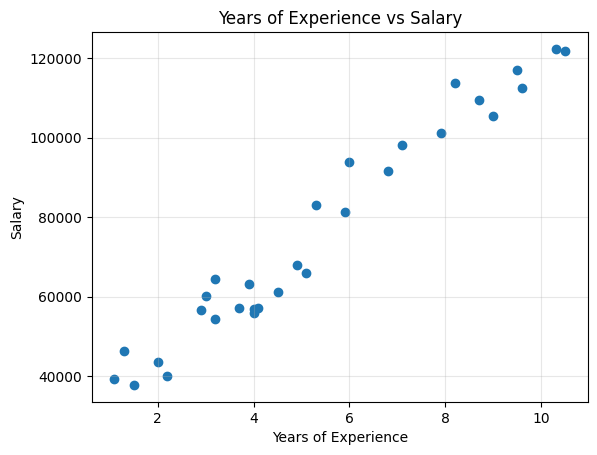

In [12]:
# plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.grid(alpha=0.3)
plt.show()

In [14]:
df[['YearsExperience']]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


## 5. Prepare Features and Target

In [15]:
X = df[['YearsExperience']]
y = df['Salary']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (30, 1)
y shape: (30,)


In [ ]:
X_train = X.iloc[0:24]
X_test = X.iloc[24:]

y_train = y.iloc[0:24]
y_test = y.iloc[24]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [33]:
np.random.seed(67)
np.random.randint(0, 10, 3)

array([3, 5, 5])

In [43]:
np.random.seed(54)
np.random.rand()

0.42018296714077386

In [47]:
l = [4, 65, 2]
np.random.shuffle(l)
l

[2, 65, 4]

## 6. Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 24
Testing samples: 6


## 7. Train Linear Regression Model

In [49]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Coefficient:', model.coef_[0])
print('Intercept:', model.intercept_)

Coefficient: 9423.815323030976
Intercept: 25321.583011776813


## 8. Model Evaluation

In [50]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

R² Score: 0.9024
Mean Absolute Error: 6286.45
Mean Squared Error: 49830096.86


## 9. Regression Line — Training Data

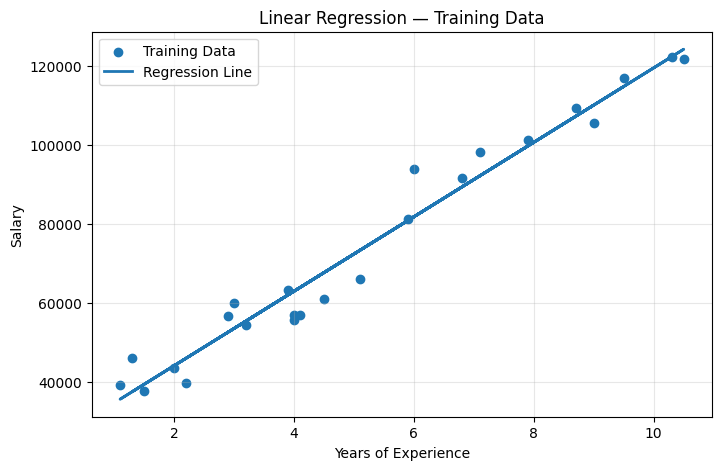

In [51]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label='Training Data')
plt.plot(X_train, model.predict(X_train), linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression — Training Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Regression Line — Testing Data

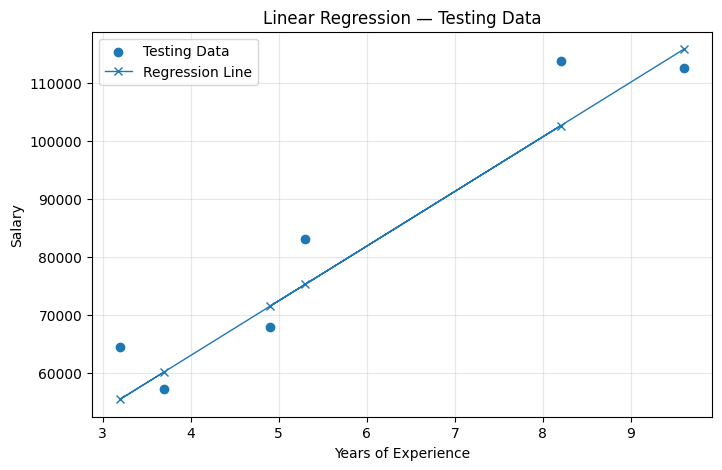

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label='Testing Data')
plt.plot(X_test, y_pred, linewidth=1, label='Regression Line', marker='x',)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression — Testing Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [58]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [57]:
y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

## 11. Save the Trained Model

In [59]:
model_path = 'salary_linear_regression.joblib'
joblib.dump(model, model_path)

print(f'Model saved to: {model_path}')

Model saved to: salary_linear_regression.joblib


## 12. Load Model and Make a Prediction

In [ ]:
loaded_model = joblib.load('salary_linear_regression.joblib')

years = 8
predicted_salary = loaded_model.predict([[years]])[0]

print(f'Predicted salary for {years} years of experience: {predicted_salary:,.2f}')